##Importación de Librerías y Carga de Datos

Asegúrate de mantener la semilla aleatoria en 42, ya que la reproducibilidad es un punto clave en la evaluación transversal del proyecto.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Herramientas de Clustering
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Semilla de reproducibilidad
RANDOM_STATE = 42

# Carga de datos
ventas = pd.read_csv('../data/processed/fact_ventas.csv', sep=';')
clientes = pd.read_csv('../data/processed/dim_cliente.csv', sep=';')
productos = pd.read_csv('../data/processed/dim_producto.csv', sep=';')

ventas['fecha'] = pd.to_datetime(ventas['fecha'])

##Construcción de Variables RFM

Vamos a calcular cuándo fue la última compra del cliente (Recencia), cuántas veces ha comprado (Frecuencia) y cuánto dinero ha gastado en total (Monto).

In [3]:
# Definimos la fecha de referencia para la recencia
fecha_actual = ventas['fecha'].max()

# Calculamos el importe real por línea de venta
ventas['importe'] = ventas['cantidad'] * ventas['precio_unitario_lista'] * (1 - ventas['descuento_pct'].fillna(0))

# Agrupamos a nivel de cliente
rfm = ventas.groupby('id_cliente').agg(
    recencia=('fecha', lambda x: (fecha_actual - x.max()).days),
    frecuencia=('id_venta', 'nunique'),
    monto=('importe', 'sum')
).reset_index()

# Verificamos la tabla
print(rfm.head())

   id_cliente  recencia  frecuencia  monto
0           1        88          14  496.5
1           2        18           9  400.3
2           3        37           7  212.8
3           4        33          16  565.0
4           5        37           7  404.8


##Escalamiento de Variables

Los algoritmos basados en distancias (como K-Means) son muy sensibles a la magnitud de las variables. El monto puede estar en miles, mientras que la frecuencia puede ser de 1 a 10. Por eso, debemos estandarizarlos.

In [4]:
# Seleccionamos solo las variables numéricas para el modelo
X = rfm[['recencia', 'frecuencia', 'monto']]

# Estandarizamos (media 0, desviación estándar 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

##Determinación del Número Óptimo de Clusters (k)
La rúbrica exige justificar la elección de $k$ usando el método del codo y el coeficiente de silueta. Ejecuta esta celda para generar ambos gráficos y tomar la decisión.

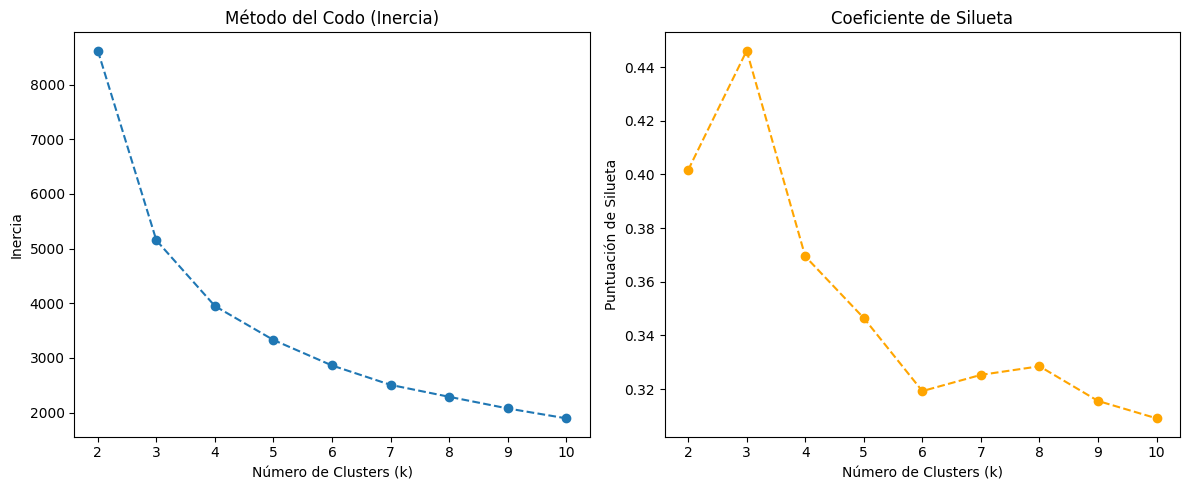

In [5]:
inercias = []
siluetas = []

rango_k = range(2, 11)

for k in rango_k:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    km.fit(X_scaled)

    inercias.append(km.inertia_)
    siluetas.append(silhouette_score(X_scaled, km.labels_))

# Gráfico del Método del Codo
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(rango_k, inercias, marker='o', linestyle='--')
plt.title('Método del Codo (Inercia)')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia')

# Gráfico del Coeficiente de Silueta
plt.subplot(1, 2, 2)
plt.plot(rango_k, siluetas, marker='o', linestyle='--', color='orange')
plt.title('Coeficiente de Silueta')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Puntuación de Silueta')

plt.tight_layout()
plt.show()

##Aplicación de K-Means y Perfilamiento
Observando los gráficos anteriores, un $k=4$ suele ser un estándar muy sólido para RFM (ej. Nuevos, Regulares, VIP, Perdidos). Vamos a aplicar el modelo con 4 clusters.

In [6]:
k_optimo = 4

# Entrenamos el modelo final
modelo_kmeans = KMeans(n_clusters=k_optimo, n_init=10, random_state=RANDOM_STATE)
rfm['cluster'] = modelo_kmeans.fit_predict(X_scaled)

# Perfilamiento de cada segmento (promedios)
perfil_clusters = rfm.groupby('cluster')[['recencia', 'frecuencia', 'monto']].mean().round(2)
perfil_clusters['cantidad_clientes'] = rfm.groupby('cluster')['id_cliente'].count()
perfil_clusters['ticket_promedio'] = (perfil_clusters['monto'] / perfil_clusters['frecuencia']).round(2)

print("--- Perfil de los Segmentos ---")
print(perfil_clusters)

--- Perfil de los Segmentos ---
         recencia  frecuencia   monto  cantidad_clientes  ticket_promedio
cluster                                                                  
0          104.71        4.77  159.62               2206            33.46
1           41.63       14.77  753.14                567            50.99
2           62.21        9.19  379.32               1537            41.28
3          464.69        2.52   96.62                690            38.34


##Asignación de Nombres y Categorías Preferidas
Para agregar valor de negocio (y cumplir con el detalle del informe), vamos a cruzar esto para ver qué compran y ponerles nombres comerciales.  (Nota: Deberás ajustar la función `asignar_nombre_segmento` basándote en los promedios que te arroje la celda anterior).

In [8]:
# Lógica sugerida (ajusta los clústeres según los resultados numéricos de tu perfilamiento)
def asignar_nombre_segmento(cluster_id):
    # Ejemplo genérico: reemplaza 0, 1, 2, 3 según quién tiene más monto/frecuencia
    nombres = {
        0: 'Leales / Frecuentes',
        1: 'En Riesgo / Inactivos',
        2: 'Campeones / VIP',
        3: 'Nuevos / Esporádicos'
    }
    return nombres.get(cluster_id, 'Otros')

rfm['nombre_segmento'] = rfm['cluster'].apply(asignar_nombre_segmento)

# Unir con clientes y exportar
export_pbi_segmentacion = rfm[['id_cliente', 'cluster', 'nombre_segmento', 'recencia', 'frecuencia', 'monto']]

ruta_salida_segmentacion = '../data/processed/segmentos_clientes.csv'
export_pbi_segmentacion.to_csv(ruta_salida_segmentacion, sep=';', index=False)
print(f"Segmentación exportada exitosamente a {ruta_salida_segmentacion}")

Segmentación exportada exitosamente a segmentos_clientes.csv
